# Transformers with PyTorch — Sentiment Classification

LSTMs solved the vanishing gradient problem but still process tokens
*sequentially* — each step depends on the previous hidden state. This
serial dependency limits parallelism and makes training on long sequences slow.

**Transformers** (Vaswani et al., 2017) discard recurrence entirely.
Every position attends directly to every other position in a single
parallel operation — **self-attention**.

**Why self-attention beats recurrence for long-range dependencies:**
- RNN: information from step 1 reaches step 100 through 99 sequential
  multiplications → gradient degradation.
- Transformer: step 1 and step 100 are connected in *one* attention step.
  Distance doesn't matter.

**Architecture (encoder-only, like BERT):**
```
Token indices  (B, L)
  → Embedding + Positional Encoding   (B, L, d_model)
  → N × TransformerEncoderLayer:
        Multi-Head Self-Attention  →  Add & LayerNorm
        Feed-Forward Network       →  Add & LayerNorm
  → Masked mean pool (real tokens)    (B, d_model)
  → Linear                            (B,)   one logit; the sigmoid is inside the loss
```

> **Shape notation used throughout this notebook:**
> `B` = batch size (reviews per batch), `L` = sequence length (words per review),
> `d_model` = embedding / hidden dimension.

We use the same `movie_reviews` data and preprocessing as Lessons 03 and 06, so you can
compare the Transformer directly with the bag of embeddings and with plain self-attention.


**(SOLUTION)**

> 📖 [Alammar — The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)

## Visual companions

Open these alongside the notebook rather than instead of it.

- [**The Illustrated Transformer**](https://jalammar.github.io/illustrated-transformer/) — Jay Alammar, 2018. Worth reading start to finish once before you write any of the code below; seeing the whole shape first makes the details cheaper.
- [**Transformer Explainer**](https://poloclub.github.io/transformer-explainer/) — Cho et al., CHI 2026. A live GPT-2 in the browser. Type a sentence and watch the score matrix change; keep it open in a second tab while you work through this notebook.
- **Book chapter 07, *Where Q, K and V Come From*** — the backward pass of everything here, and the companion notebook `07_attention_backprop`.

## Step 1: Imports

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import nltk
import random
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: mps


## Key Concept: Devices and `.to(device)`

PyTorch can run computations on the **CPU** or a **GPU** (NVIDIA CUDA or
Apple Silicon MPS). Moving a tensor or model to a device means its data and
computations live there.

```python
device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')

model = MyModel().to(device)   # moves all weight tensors to device
X = X.to(device)               # moves input data to the same device
```

**Rule:** model and data must be on the *same* device — mixing them raises
a `RuntimeError`. Call `.to(device)` on both.

> 📖 [PyTorch — CUDA semantics](https://pytorch.org/docs/stable/notes/cuda.html)


## Key Concept: `Dataset` and `DataLoader`

`DataLoader` handles batching, shuffling, and parallel data loading so your
training loop stays simple.

```python
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_train, y_train)   # pairs inputs with labels
loader  = DataLoader(dataset,
                     batch_size=64,
                     shuffle=True)           # reshuffles every epoch

for Xb, yb in loader:                       # Xb: (64, ...) one mini-batch
    ...
```

Key parameters:
- `batch_size` — number of samples per gradient update
- `shuffle=True` — randomize order each epoch (always use for training)
- `num_workers` — background processes for loading. In a notebook on macOS, `0` is
  often the fastest, because the datasets here are small (book Chapter 03)

> 📖 [PyTorch — Writing a Custom Dataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html)


## Step 2: Load Movie Reviews (same as Lesson 03)

In [2]:
from nltk.corpus import movie_reviews

random.seed(42)
docs = [(movie_reviews.words(fid), cat)
        for cat in movie_reviews.categories()
        for fid in movie_reviews.fileids(cat)]
random.shuffle(docs)

MAX_VOCAB = 10000
MAX_LEN   = 600      # same as Lessons 03 and 06

# Vocabulary from the TRAINING reviews only (the first 80% after the shuffle) —
# counting the test reviews too would leak test information into the model.
n_train   = int(0.8 * len(docs))
all_words = [w.lower() for ws, _ in docs[:n_train] for w in ws]
freq      = Counter(all_words)
# Index 0 = <PAD>  (zeroed out by padding_idx)
# Index 1 = <UNK>  (any word not in top 9998)
vocab     = {'<PAD>': 0, '<UNK>': 1}
for w, _ in freq.most_common(MAX_VOCAB - 2):
    vocab[w] = len(vocab)

def encode(words, vocab, max_len):
    tokens = [vocab.get(w.lower(), 1) for w in words][:max_len]
    return tokens + [0] * (max_len - len(tokens))   # pad to exactly max_len

X_data = [encode(ws, vocab, MAX_LEN) for ws, _ in docs]
y_data = [1 if label == 'pos' else 0 for _, label in docs]

# X_tensor: (2000, 600) — dtype=long for nn.Embedding lookup
# y_tensor: (2000,)     — float32, as BCEWithLogitsLoss requires
X_tensor = torch.tensor(X_data, dtype=torch.long)
y_tensor = torch.tensor(y_data, dtype=torch.float32)
print('X:', X_tensor.shape, '  y:', y_tensor.shape)

X: torch.Size([2000, 600])   y: torch.Size([2000])


## Step 3: DataLoaders

In [3]:
split = int(0.8 * len(X_tensor))         # 1600 train / 400 test
X_train, X_test = X_tensor[:split], X_tensor[split:]   # (1600, 600) / (400, 600)
y_train, y_test = y_tensor[:split], y_tensor[split:]   # (1600,)    / (400,)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=32)
print(f'Train batches: {len(train_loader)}  Test batches: {len(test_loader)}')

Train batches: 50  Test batches: 13


## Key Concept: Self-Attention (Recap from Lesson 06)

You implemented scaled dot-product attention and multi-head self-attention from
scratch in Lesson 06 — refer back there for the full derivation.

In brief:
- **Queries, Keys, Values** — the input is projected three ways; similarity between
  Q and K determines how much each position attends to every other position
- **Scaling** — divide by `√d_k` to prevent softmax saturation
- **Multi-head** — run `H` independent attention functions and concatenate;
  each head can specialize in a different type of relationship

This lesson builds on that foundation and adds the components that make a
**full Transformer encoder**: positional encoding, a feed-forward sublayer,
residual connections, and layer normalization.

## Step 4: Scaled Dot-Product Attention

In [4]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (B, H, L_q, d_k)
    K: (B, H, L_k, d_k)
    V: (B, H, L_k, d_k)
    Returns: output (B, H, L_q, d_k), weights (B, H, L_q, L_k)
    """
    d_k = Q.size(-1)
    # K.transpose(-2,-1): (B,H,L_k,d_k) → (B,H,d_k,L_k)
    # scores: (B,H,L_q,d_k) @ (B,H,d_k,L_k) = (B,H,L_q,L_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))

    weights = F.softmax(scores, dim=-1)              # (B,H,L_q,L_k) — rows sum to 1

    # (B,H,L_q,L_k) @ (B,H,L_k,d_k) = (B,H,L_q,d_k)
    output = torch.matmul(weights, V)

    return output, weights

### Concept Check: Scaled Dot-Product Attention — Answers

**Q1.** The score matrix has shape `(B, H, L, L)`. What does entry `[b, h, i, j]`
represent? What does it mean if this value is very large?

**→** Entry `[b, h, i, j]` is the raw (pre-softmax) attention score of
token `i` attending to token `j` in head `h` of batch sample `b`.
A large positive value → after softmax, token `i` will strongly weight
token `j`'s value vector when forming its output representation.

**Q2.** We scale by `1/√d_k`. If `d_k = 64` and you did NOT scale, what would
happen to the softmax as `d_k` grows? (Hint: the variance of a dot product of two
random vectors whose components have variance 1 grows linearly with dimension.)

**→** The variance of a dot product of two `d_k`-dimensional random vectors with
unit-variance components is `d_k`. (Two random *unit* vectors are different: their dot
product has variance `1/d_k`.) Without `√d_k` scaling, large `d_k` pushes scores
into extreme regions where `softmax'(x) → 0` — vanishing gradients in the
attention weights. Dividing by `√d_k` keeps the variance ≈ 1 regardless
of dimension.

**Q3.** After softmax, each row of the weight matrix sums to 1.
What is the output when the weight is `[1, 0, 0, ..., 0]` (all attention on
the first token)? When it is uniform `[1/L, 1/L, ...]`?

**→** - Weight `[1, 0, ..., 0]`: output = V[0] — the model copies token 0's
  value vector exactly, ignoring everything else.
- Uniform weights `[1/L, ...]`: output = mean(V) — unweighted average of
  all value vectors. This is equivalent to "paying equal attention to
  everything" — essentially no attention.

## Key Concept: Multi-Head Attention (Recap from Lesson 06)

Same `MultiHeadSelfAttention` class from Lesson 06, re-defined here so this
notebook runs standalone.  See Lesson 06 for the full explanation of
`split_heads`, `merge_heads`, and the `W_o` output projection.

## Step 5: Multi-Head Attention

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def split_heads(self, x):
        B, L, _ = x.shape
        # (B, L, d_model) → (B, L, H, d_k) → (B, H, L, d_k)
        return x.view(B, L, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, Q, K, V, mask=None):
        B = Q.size(0)
        Q = self.split_heads(self.W_q(Q))   # (B, H, L, d_k)
        K = self.split_heads(self.W_k(K))   # (B, H, L, d_k)
        V = self.split_heads(self.W_v(V))   # (B, H, L, d_k)

        out, weights = scaled_dot_product_attention(Q, K, V, mask)

        # (B, H, L, d_k) → (B, L, H, d_k) → (B, L, d_model)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.num_heads * self.d_k)
        return self.W_o(out), weights

### Concept Check: Multi-Head Attention — Answers

**Q1.** With `d_model=128` and `num_heads=4`, each head operates in `d_k=32`
dimensions. If instead `num_heads=8`, what is `d_k`? What is the total number
of parameters in `W_q` either way?

**→** `d_k = 128/8 = 16` per head.
Parameter count of `W_q`: always `d_model × d_model = 128 × 128 = 16 384`
regardless of `num_heads`. Splitting into heads doesn't change the total
number of parameters — it restructures the computation.

**Q2.** `split_heads` reshapes `(B, L, d_model)` → `(B, H, L, d_k)` using
`.view` followed by `.transpose(1, 2)`. Why is `.contiguous()` needed *after*
transposing when you later call `.view`?

**→** `.transpose()` returns a *view* with non-contiguous memory layout.
`.view()` requires contiguous memory — it reads elements in row-major order.
`.contiguous()` makes a new copy in row-major layout before `.view()`.

**Q3.** The output projection `W_o` mixes information across heads.
What would happen if you removed `W_o` and just returned the concatenated
head outputs directly?

**→** Without `W_o`, the concatenated heads would be used directly.
`W_o` learns how to *mix* the contributions of different heads into a unified
representation. Without it, head outputs are simply concatenated with no
learned weighting — the model loses the ability to decide how much each head's
output should influence the final representation.

## Key Concept: Positional Encoding

Self-attention is **permutation-equivariant**: swapping two tokens swaps the
corresponding rows and columns of the attention weights, and nothing else changes. The model cannot tell whether "cat
bites dog" differs from "dog bites cat" without positional information.

**Solution:** Add a positional signal to the embedding before the first layer.
The "Attention Is All You Need" paper uses fixed sinusoidal encodings:

```
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

**Why sinusoids?**
- Each position gets a unique `d_model`-dimensional fingerprint.
- The model can learn relative positions: `PE(pos + k)` is a *linear function*
  of `PE(pos)` for any fixed offset `k` — so relative distance is linearly
  decodable.
- Unlike learned positional embeddings, sinusoids generalize to sequence
  lengths not seen during training.

**Shape:** `pe` is a buffer of shape `(1, max_len, d_model)`.
It is added (broadcast) to the embedding: `x + pe[:, :L]`.


## Step 6: Positional Encoding

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)                          # (max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)   # (max_len, 1)
        # div: one value per pair of dims; exp(-2i/d_model * log(10000))
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float)
                        * -(math.log(10000.0) / d_model))             # (d_model//2,)

        pe[:, 0::2] = torch.sin(pos * div)    # (max_len, d_model//2)
        pe[:, 1::2] = torch.cos(pos * div)    # (max_len, d_model//2)

        # Buffer: not a parameter (won't be updated by the optimizer)
        # but moves to the correct device with model.to(device)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):   # x: (B, L, d_model)
        # pe[:, :L] slices (1, L, d_model); broadcast adds over B
        return self.dropout(x + self.pe[:, :x.size(1)])

### Concept Check: Positional Encoding — Answers

**Q1.** A purely sinusoidal PE is *fixed* (not learned). What is one advantage
of this over learned positional embeddings? What is one disadvantage?

**→** *Advantage of fixed sinusoids*: generalize to longer sequences than seen
in training (positions beyond `max_len` can still be computed analytically).
*Disadvantage*: the specific frequency structure may not be optimal for the
task — learned PEs can adapt to the data.

**Q2.** The PE buffer has shape `(1, max_len, d_model)` and is added to
embeddings of shape `(B, L, d_model)`. What broadcasting rule makes this work?

**→** `pe` shape `(1, max_len, d_model)` broadcasts over the batch
dimension `B`. NumPy/PyTorch broadcasting aligns trailing dimensions:
`(B, L, d_model) + (1, L, d_model)` → `(B, L, d_model)`. The `1` in the
first dimension is automatically replicated `B` times.

**Q3.** If you shuffled the tokens in a sentence and added the *same* shuffled
positional encodings, would the transformer produce the same output?
What if you shuffled tokens but kept positional encodings in original order?

**→** If you shuffle tokens *and* shuffle positional encodings together,
the model sees the same (token, position) pairs in a different order —
output representations are permuted accordingly, but the model's "understanding"
is the same. If you shuffle tokens but keep PEs at original positions,
the model receives incorrect positional assignments — it would, for example,
assign "position 0" to what was originally the third word. Predictions would
be degraded because the positional context is wrong.

## Key Concept: Transformer Encoder Layer

Each encoder layer contains two sub-layers, each wrapped in a
**residual connection** and followed by **Layer Normalization**:

```
Sub-layer 1:  x = LayerNorm(x + Dropout(MultiHeadAttention(x, x, x)))
Sub-layer 2:  x = LayerNorm(x + Dropout(FeedForward(x)))
```

**Why residual connections?**
`x + f(x)` lets gradients flow directly back through the addition operation
(gradient of addition w.r.t. both inputs is 1). Even if `f(x)` produces
near-zero gradients, the residual path keeps learning alive. This is what
makes 12-96 layer transformers trainable.

**Why LayerNorm and not BatchNorm?**
BatchNorm normalizes across the *batch* dimension — its statistics depend on
batch size and order, which makes it unstable for variable-length sequences
(different positions would have different batch statistics).
LayerNorm normalizes across the *feature* dimension for each token
independently — stable regardless of batch size or sequence length.

**Feed-Forward Network:**
`d_model → d_ff → d_model` (typically `d_ff = 4 × d_model`).
This per-position MLP is where most of the model's "knowledge" is stored.
In practice it accounts for ~2/3 of a transformer's parameters.


## Step 7: Transformer Encoder Layer

In [7]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, num_heads)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask=None):   # x: (B, L, d_model)
        # Sub-layer 1: self-attention (Q=K=V=x) + residual + LayerNorm
        attn_out, _ = self.attn(x, x, x, mask)       # (B, L, d_model)
        x = self.norm1(x + self.drop(attn_out))        # (B, L, d_model)

        # Sub-layer 2: position-wise FFN + residual + LayerNorm
        x = self.norm2(x + self.drop(self.ff(x)))      # (B, L, d_model)
        return x

### Concept Check: Residuals & Layer Normalization — Answers

**Q1.** The residual connection is `x = norm(x + f(x))` rather than
`x = f(x)`. During backpropagation, what is the gradient of the addition
w.r.t. the identity branch (the raw `x`)? Why does this prevent vanishing?

**→** The gradient of `z = x + f(x)` w.r.t. `x` is `1 + f'(x)`.
The `1` ensures the gradient is at least 1 — it never vanishes through
the residual path even if `f'(x) → 0`. This is the key insight behind
ResNets and Transformers: residuals provide a "gradient highway" that
bypasses potentially small `f'(x)`.

**Q2.** LayerNorm normalizes each token's `d_model`-dimensional vector to
have mean 0 and variance 1. BatchNorm normalizes across the batch dimension.
Give one concrete reason why BatchNorm is problematic for variable-length
text sequences.

**→** BatchNorm computes statistics (mean, variance) across the batch
dimension for each sequence position. With variable-length sequences padded
to the same length, padding tokens (zeros) would corrupt these statistics —
their distributions are completely different from real tokens. LayerNorm
normalizes *within* each token's feature vector independently, so it is
unaffected by padding or batch composition.

**Q3.** The feed-forward network (FFN) is applied **independently to each
position** — it has no awareness of adjacent tokens. If attention already
mixes information across positions, what is the FFN's role?

**→** The FFN acts as a position-wise **non-linear transformation** and
**memory store**. Research suggests it acts like a key-value memory that
stores factual associations (e.g., "Paris is the capital of...") while
attention handles contextual routing. Removing the FFN would force all
transformations to be attention-mediated, reducing model capacity
significantly.

## Step 8: Full Sentiment Transformer

In [8]:
class SentimentTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, num_layers=2,
                 d_ff=256, max_len=600, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):                           # x: (B, L) token indices
        pad  = (x == 0)                             # (B, L) True at <PAD>
        mask = pad[:, None, None, :]                # (B, 1, 1, L): no query attends to a PAD key
        emb = self.pos_enc(self.embedding(x))       # (B, L, d_model): embed + pos enc
        for layer in self.layers:
            emb = layer(emb, mask)                   # (B, L, d_model): each encoder layer
        keep   = (~pad).unsqueeze(-1).float()                          # (B, L, 1)
        pooled = (emb * keep).sum(1) / keep.sum(1).clamp_min(1.0)      # (B, d_model): masked mean
        return self.fc(pooled).squeeze(-1)          # (B,): one logit per review

vocab_size = len(vocab)
model = SentimentTransformer(vocab_size).to(device)
print(model)
print('Parameters:', sum(p.numel() for p in model.parameters()))

SentimentTransformer(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (layers): ModuleList(
    (0-1): 2 x TransformerEncoderLayer(
      (attn): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=False)
        (W_k): Linear(in_features=128, out_features=128, bias=False)
        (W_v): Linear(in_features=128, out_features=128, bias=False)
        (W_o): Linear(in_features=128, out_features=128, bias=False)
      )
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (drop): Dropout(p=0.2, inplace=False)
    )
  )
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Par

## Key Concept: factor the training loop

From here on, every lesson has a training loop. Write it once, as two functions, and
every later lesson can reuse them unchanged:

```python
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                      # dropout ON, batchnorm updating
    total = 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = criterion(model(Xb), yb)
        optimizer.zero_grad()          # gradients accumulate; clear them first
        loss.backward()
        optimizer.step()
        total += loss.item() * Xb.size(0)
    return total / len(loader.dataset)

@torch.no_grad()                       # no graph, no gradients, less memory
def evaluate(model, loader, criterion, device):
    model.eval()                       # dropout OFF — this is not optional
    total, correct = 0.0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        out = model(Xb)
        total += criterion(out, yb).item() * Xb.size(0)
        correct += ((out >= 0.5).float() == yb).sum().item()   # out = probabilities
        # if the model returns logits, use (out >= 0) — the same threshold
    return total / len(loader.dataset), correct / len(loader.dataset)
```

Three things this buys beyond tidiness. `model.train()` and `model.eval()` are stated
exactly once each, so you cannot forget one. Weighting by `Xb.size(0)` makes the epoch
loss correct even when the last batch is short — a plain mean over batches is subtly
wrong. And having `evaluate` separate means measuring validation loss costs one line, so
you will actually do it.

## Key Concept: learning rate schedules

A constant learning rate is a compromise: large enough to make progress early is usually
too large to settle later. A schedule resolves it.

```python
optimizer = optim.Adam(model.parameters(), lr=3e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    train_one_epoch(...)
    scheduler.step()          # once per EPOCH here — see below
```

**Step it in the right place.** `CosineAnnealingLR` with `T_max=EPOCHS` expects one call
per epoch. A per-batch scheduler (`OneCycleLR`, or warmup) expects one call per *batch*,
and `T_max` must then be `EPOCHS * len(loader)`. Stepping an epoch scheduler per batch
decays the rate to nothing within the first epoch, and the symptom is a loss that drops
promisingly and then simply stops moving.

**Warmup** — starting near zero and ramping up over the first few hundred steps — matters
for transformers specifically. Early in training, Adam's second-moment estimate is still
inaccurate and the updates are large and noisy. One large early step can make an attention
head sharp before it is useful (book Chapter 07), and post-norm transformers are
especially sensitive (book Chapter 08).

## Key Concept: keep the best epoch, not the last

Validation loss usually reaches its minimum before training ends, and then rises while
training loss keeps falling. If you keep the weights you happen to have at the end, you
keep an overfitted model and throw away the good one you already had.

```python
best = float("inf")
for epoch in range(EPOCHS):
    train_one_epoch(...)
    val_loss, val_acc = evaluate(...)
    if val_loss < best:
        best = val_loss
        torch.save(model.state_dict(), "best.pt")     # weights only, not the object

model.load_state_dict(torch.load("best.pt"))          # restore before reporting anything
```

Save the `state_dict`, not the model. Pickling the model object ties the file to your
class definitions and import paths, so it breaks the moment you rename anything; a
`state_dict` is just a dictionary of tensors and loads into any equivalent architecture.

## Step 9: Train

In [9]:
criterion    = nn.BCEWithLogitsLoss()   # takes raw logits; applies the sigmoid internally
optimizer    = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
# weight_decay adds L2 regularization to the optimizer: effectively penalizes
# large weights by subtracting a small fraction of them each step (helps prevent overfit)
train_losses = []

for epoch in range(10):
    model.train()
    total = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)   # Xb: (32, 600)  yb: (32,)

        # Forward pass through: embedding → positional encoding → N encoder layers
        # → masked mean pool → classifier head. The multi-head attention scores are
        # computed and stored in the graph at this point.
        out  = model(Xb)                         # (32,) raw logits, same shape as yb

        loss = criterion(out, yb)
        optimizer.zero_grad()
        loss.backward()   # gradients flow through attention weights, FFN, embeddings
        optimizer.step()

        total += loss.item()
    avg = total / len(train_loader)
    train_losses.append(avg)
    print(f'Epoch {epoch+1:2d} | Loss: {avg:.4f}')


Epoch  1 | Loss: 0.7018


Epoch  2 | Loss: 0.6878


Epoch  3 | Loss: 0.6758


Epoch  4 | Loss: 0.6512


Epoch  5 | Loss: 0.6313


Epoch  6 | Loss: 0.6082


Epoch  7 | Loss: 0.6011


Epoch  8 | Loss: 0.5778


Epoch  9 | Loss: 0.5607


Epoch 10 | Loss: 0.5395


## Step 10: Evaluate

In [10]:
model.eval()
correct = total = 0
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        preds  = (model(Xb) >= 0).float()          # (32,) logit >= 0 means probability >= 0.5
        correct += (preds == yb).sum().item()
        total   += yb.size(0)
print(f'Transformer Test accuracy: {correct/total*100:.1f}%')

Transformer Test accuracy: 65.0%


## Step 11: Compare with the Bag of Embeddings and Self-Attention (Lessons 03 & 06)

Same data, same preprocessing:
  Bag of embeddings (Lesson 03): 80.8%
  Self-attention    (Lesson 06): 76.0%
  Transformer       (this one) : 65.0%
Parameters — Transformer: 1,544,065


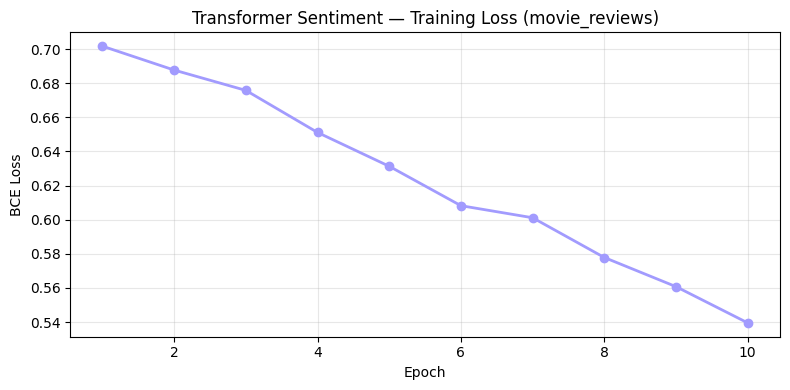

In [11]:
print("Same data, same preprocessing:")
print("  Bag of embeddings (Lesson 03): 80.8%")
print("  Self-attention    (Lesson 06): 76.0%")
print(f"  Transformer       (this one) : {correct/total*100:.1f}%")
print(f"Parameters — Transformer: {sum(p.numel() for p in model.parameters()):,}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, 'o-', color='#a29bfe', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Transformer Sentiment — Training Loss (movie_reviews)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Reading the comparison honestly

Two different things are holding this Transformer back, and the numbers above mix them:

- **At 10 epochs it is undertrained.** The training loss is still falling (about 0.54 at
  epoch 10). Train it longer and the test accuracy rises — measured with this exact
  setup: about 66% at epoch 10, 72% at 15, and 74–75% from epoch 25 on.
- **Trained to convergence it overfits, and still loses.** By epoch 30 training accuracy
  is above 99%, while test accuracy stays near 75% — below the 80.8% of the bag of
  embeddings.

So the gap is not a bug. A model with little built-in structure has more to learn, and
1,600 reviews are not enough to learn it. The averaging baseline, with no attention and
no positional information, has exactly the right prior for sentiment. Transformers win
when there is enough data — which is why the models that made them famous were trained
on billions of tokens, not 2,000 reviews.


## Step 12: Visualize Attention Weights

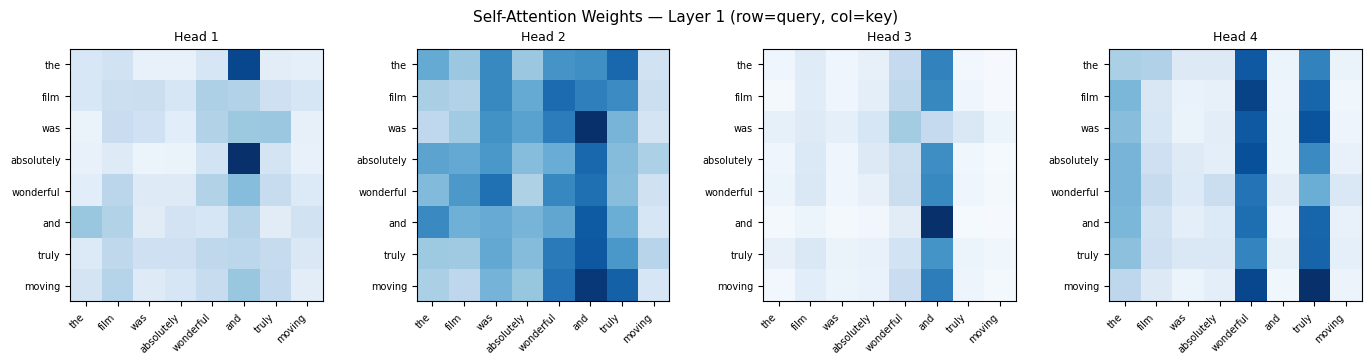

In [12]:
def get_attention_weights(model, tokens, device):
    """Return (H, L, L) attention weights from the first encoder layer."""
    model.eval()
    with torch.no_grad():
        x   = torch.tensor([tokens], dtype=torch.long, device=device)
        pad_mask = (x == 0)[:, None, None, :]                 # ignore <PAD> keys
        emb = model.pos_enc(model.embedding(x))              # (1, L, d_model)
        _, weights = model.layers[0].attn(emb, emb, emb, pad_mask)   # (1, H, L, L)
    return weights[0].cpu()                                   # (H, L, L)

test_text  = "the film was absolutely wonderful and truly moving"
raw_tokens = [vocab.get(w, 1) for w in test_text.split()]
padded     = raw_tokens + [0] * (MAX_LEN - len(raw_tokens))
words      = test_text.split()
L          = len(words)

attn = get_attention_weights(model, padded, device)   # (H, L, L)

fig, axes = plt.subplots(1, min(4, attn.size(0)), figsize=(14, 3.5))
for h, ax in enumerate(axes):
    mat = attn[h, :L, :L].numpy()
    ax.imshow(mat, cmap='Blues', vmin=0)
    ax.set_xticks(range(L)); ax.set_xticklabels(words, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(L)); ax.set_yticklabels(words, fontsize=7)
    ax.set_title(f'Head {h+1}', fontsize=9)
plt.suptitle('Self-Attention Weights — Layer 1 (row=query, col=key)', fontsize=11)
plt.tight_layout()
plt.show()

## Step 13: Visualize the Transformer Architecture

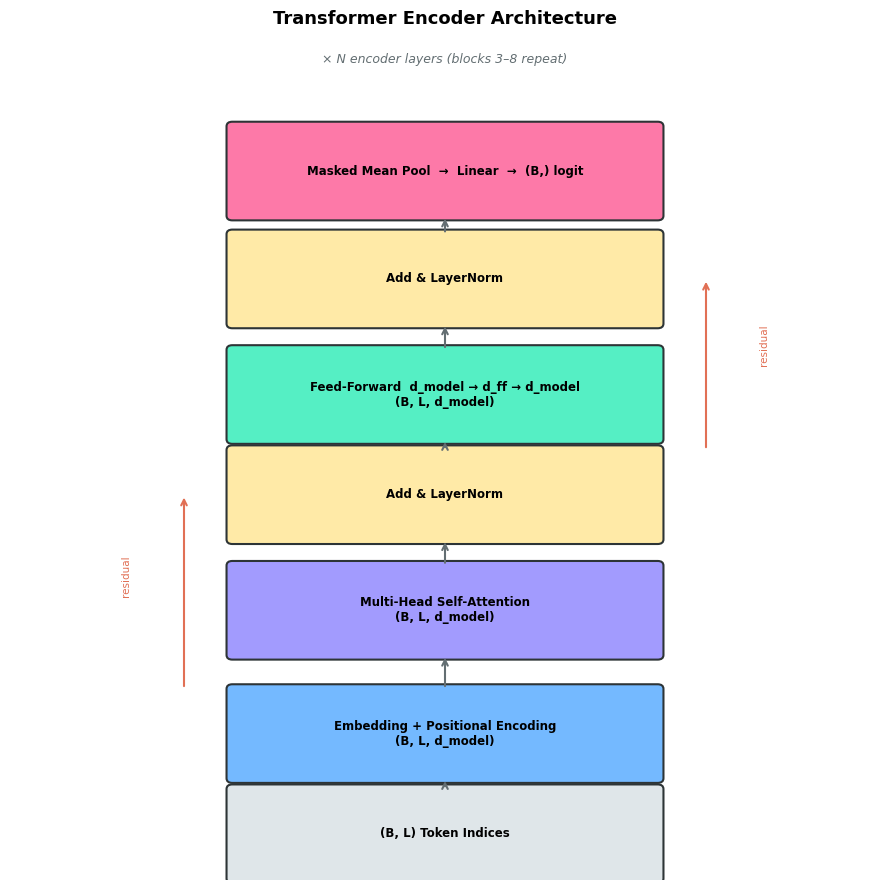

In [13]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_xlim(0, 9); ax.set_ylim(0, 11); ax.axis('off')
ax.set_title('Transformer Encoder Architecture', fontsize=13, fontweight='bold')

blocks = [
    (4.5, 0.6,  '(B, L) Token Indices',                                    '#dfe6e9'),
    (4.5, 1.9,  'Embedding + Positional Encoding\n(B, L, d_model)',        '#74b9ff'),
    (4.5, 3.5,  'Multi-Head Self-Attention\n(B, L, d_model)',              '#a29bfe'),
    (4.5, 5.0,  'Add & LayerNorm',                                          '#ffeaa7'),
    (4.5, 6.3,  'Feed-Forward  d_model → d_ff → d_model\n(B, L, d_model)','#55efc4'),
    (4.5, 7.8,  'Add & LayerNorm',                                          '#ffeaa7'),
    (4.5, 9.2,  'Masked Mean Pool  →  Linear  →  (B,) logit',             '#fd79a8'),
]
for x, y, label, color in blocks:
    rect = mpatches.FancyBboxPatch((x-2.2, y-0.58), 4.4, 1.16,
                                    boxstyle='round,pad=0.06',
                                    facecolor=color, edgecolor='#2d3436', lw=1.5)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=8.5, fontweight='bold')

for i in range(len(blocks)-1):
    y0, y1 = blocks[i][1], blocks[i+1][1]
    ax.annotate('', xy=(4.5, y1-0.58), xytext=(4.5, y0+0.58),
                arrowprops=dict(arrowstyle='->', color='#636e72', lw=1.5))

# Residual bypass arrows
ax.annotate('', xy=(1.8, 5.0), xytext=(1.8, 2.48),
            arrowprops=dict(arrowstyle='->', color='#e17055', lw=1.5))
ax.text(1.2, 3.7, 'residual', ha='center', fontsize=7.5, color='#e17055', rotation=90)

ax.annotate('', xy=(7.2, 7.8), xytext=(7.2, 5.58),
            arrowprops=dict(arrowstyle='->', color='#e17055', lw=1.5))
ax.text(7.8, 6.7, 'residual', ha='center', fontsize=7.5, color='#e17055', rotation=90)

ax.text(4.5, 10.6, '× N encoder layers (blocks 3–8 repeat)', ha='center',
        fontsize=9, color='#636e72', style='italic')
plt.tight_layout()
plt.show()

### Final Concept Check: Transformers vs Recurrent Models — Answers

**Q1.** Self-attention has `O(L²)` memory complexity (the `L×L` score matrix).
For a sequence of length 1000, how much larger is the score matrix than for
length 100? Why is this a practical concern for document-level tasks?

**→** Score matrix for L=1000 is 1 000 000 entries; for L=100 it's 10 000.
That's 100× more memory for 10× longer sequences — quadratic growth.
This is why standard transformers are impractical for very long documents
(books, code files). Sparse attention reduces the cost: the Sparse Transformer to
O(L√L), Longformer and BigBird to O(L). FlashAttention keeps the exact O(L²)
arithmetic but never stores the full matrix, so memory becomes O(L).

**Q2.** LSTM processes tokens left-to-right, so the representation of token
`t` is conditioned only on tokens `1..t`. Transformer self-attention can
attend to tokens before *and* after `t` simultaneously. What does this
property enable that an LSTM encoder cannot do as directly?

**→** Bidirectionality: every token can attend to both past *and future*
tokens in a single pass. This is what makes BERT-style models so powerful
for understanding — the representation of "bank" in "river bank" benefits
from seeing "river" which appears *after* it. A left-to-right LSTM requires
a second reverse pass (BiLSTM) to achieve the same, with architectural
overhead.

**Q3.** You trained an encoder-only transformer for classification. Name one
task that would require an *encoder-decoder* transformer and explain what the
decoder adds.

**→** Example: **machine translation**. The decoder generates output tokens
one at a time, attending to both previous output tokens (self-attention) and
the full source-language encoder output (cross-attention). The encoder-only
architecture cannot generate variable-length output sequences.

**Q4.** Rank three architectures from this course — LSTM, Transformer, and the bag of
embeddings — by how much word-order structure they build in (from most to least).
Justify, and relate the ranking to the accuracies you measured.

**→** Most → least built-in order structure:
1. **LSTM** — reads strictly left to right; order is built into the computation, with
   a strong bias toward recent tokens.
2. **Transformer** — order comes only from the added positional encoding; attention
   itself is order-blind, so the model must *learn* how to use position.
3. **Bag of embeddings** — none at all: any ordering of the same tokens gives the
   identical vector.

The weaker the built-in structure, the more the model must learn from data — and the
more data it needs. On 1,600 reviews the bag of embeddings has the least to learn and a
prior that suits sentiment, which is why the more flexible models do not beat it here.